In [1]:
import os
import sys
import json
import time
import datetime
import numpy as np
import seaborn as sns
from copy import copy
from collections import defaultdict
import tqdm
from tqdm.notebook import tqdm
from types import SimpleNamespace

####### torch modules #############
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision.datasets import CIFAR100
from torchvision import transforms

import matplotlib.pyplot as plt
import matplotlib
from PIL import Image


In [2]:
def set_seed(seed):
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cpu") if not torch.cuda.is_available() else torch.device ("cuda:0")
print("using this device", device)

using this device cpu


In [3]:
import urllib.request
from urllib.error import HTTPError

data_path = "/.data_path"
checkpoint_path = "./checkpoint_path"

base_url =  "https://github.com/chenyaofo/pytorch-cifar-models/" # Added trailing slash
pretrained_files = [
    "GoogleNet_cifar100.ckpt",
    "ResNet_cifar100.ckpt",
    "ResNetPreAct_cifar100.ckpt",
    "DenseNet_cifar100.ckpt",

    "tensorboards/GoogleNet_cifar100/events.out.tfevents.googlenet",
    "tensorboards/ResNet_cifar100/events.out.tfevents.resnet",
    "tensorboards/ResNetPreAct_cifar100/events.out.tfevents.resnetpreact",
    "tensorboards/DenseNet_cifar100/events.out.tfevents.densenet"
]


os.makedirs(checkpoint_path, exist_ok = True)
for file_name in pretrained_files:
  file_path = os.path.join(checkpoint_path, file_name)
  # Create directory if file_name includes a path
  file_dir = os.path.dirname(file_path)
  if file_dir and not os.path.exists(file_dir):
      os.makedirs(file_dir, exist_ok = True)
  if not os.path.isfile(file_path):
    file_url = base_url + file_name
    print(f"Downloading this file {file_url}")
    try:
      urllib.request.urlretrieve(file_url, file_path)
    except HTTPError as e:
      print(f"Error downloading {file_url}: {e}")


Error downloading https://github.com/chenyaofo/pytorch-cifar-models/GoogleNet_cifar100.ckpt: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/ResNet_cifar100.ckpt: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/ResNetPreAct_cifar100.ckpt: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/DenseNet_cifar100.ckpt: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/tensorboards/GoogleNet_cifar100/events.out.tfevents.googlenet: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/tensorboards/ResNet_cifar100/events.out.tfevents.resnet: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch-cifar-models/tensorboards/ResNetPreAct_cifar100/events.out.tfevents.resnetpreact: HTTP Error 404: Not Found
Error downloading https://github.com/chenyaofo/pytorch

In [4]:
train_dataset = CIFAR100(root = data_path, download = True, train = True)
train_dataset

C:\Users\ACE\AppData\Roaming\Python\Python314\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset CIFAR100
    Number of datapoints: 50000
    Root location: /.data_path
    Split: Train

In [5]:
import torch.utils.data as  data

In [6]:
img_mean = (train_dataset.data/255.0).mean().item()
img_std = (train_dataset.data/255.0).std().item()


In [7]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((32, 32),scale = (0.9, 1.0),ratio = (0.2, 0.8)),
    transforms.ToTensor(),
    transforms.Normalize(img_mean, img_std)
])


test_transform = transforms.Compose([transforms.ToTensor(),
                                     transforms.Normalize(img_mean, img_std)])



train_datasets = len(train_dataset)
train_size = int(0.8 * train_datasets)
val_size = train_datasets - train_size


train_data = CIFAR100(root = data_path, train = True, download = True, transform = train_transform)
test_data = CIFAR100(root = data_path, download = True, train = False, transform = test_transform)


train_set, val_set = torch.utils.data.random_split(train_data, [train_size, val_size])


train_loader = data.DataLoader(train_set, shuffle = True, batch_size = 256, drop_last = True, pin_memory = False, num_workers = 0)
val_loader = data.DataLoader(val_set, shuffle = False,  batch_size = 256, num_workers = 0, drop_last = False)
test_loader = data.DataLoader(test_data,shuffle = False, drop_last = False, batch_size = 256)

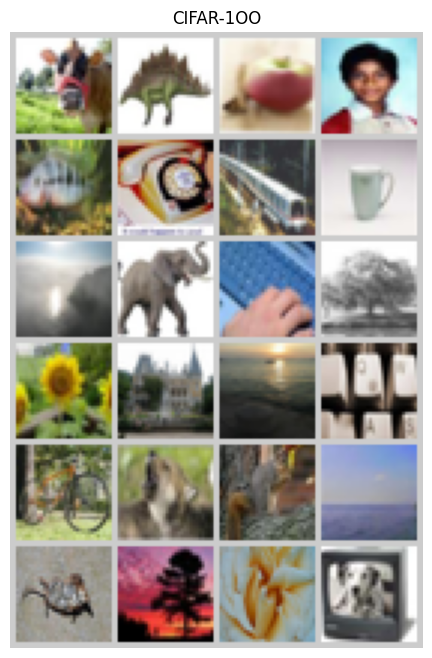

In [8]:
img_grid = [train_data[i][0] for i in range(24)]
img_grid = [Image.fromarray(train_data.data[i])for i in range(24)]
image = [test_transform(i)for i in img_grid]

img_grids = torchvision.utils.make_grid(torch.stack(image, dim = 0), nrow = 4, normalize = True, pad_value = 0.8)

img_grids = img_grids.permute(1, 2, 0)
plt.figure(figsize = (8,8))
plt.imshow(img_grids)
plt.axis("off")
plt.title("CIFAR-1OO")
plt.show()


In [9]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pytorch_lightning") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pytorch-lightning"])

import pytorch_lightning as pl

In [10]:
pl.seed_everything(42)

Seed set to 42


42

In [11]:
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor

In [12]:
from cifar_models import create_model

class lighting(pl.LightningModule):

  def __init__(self, model_name, model_params, optimizer_name, optimizer_params):
    super().__init__()

    self.save_hyperparameters()

    self.model = create_model(model_name, model_params)
    self.Crossentropyloss = nn.CrossEntropyLoss()

    # Fix: Ensure example tensor matches input image shape (batch_size, channels, height, width)
    self.example_input_array = torch.zeros((2, 3, 32, 32), dtype = torch.float32)


  def forward(self, x):
    return self.model(x)



  def configure_optimizers(self):
    if self.hparams.optimizer_name == "SGD":
      optimizer = torch.optim.SGD(self.parameters(), ** self.hparams.optimizer_params)
    elif self.hparams.optimizer_name == "AdamW":
      optimizer = torch.optim.AdamW(self.parameters(), ** self.hparams.optimizer_params)
    else:
     assert False, f"Unknown optimizer \"{self.hparams.optimizer_name}\""


    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [100, 180], gamma = 0.1)

    return [optimizer], [scheduler]


  def training_step(self, batch, batch_idx):
    img, label = batch
    pred = self.model(img)
    acc = (pred.argmax(dim = 1)== label).float().mean()
    loss = self.Crossentropyloss(pred, label)


    self.log("train_acc", acc, on_step = False, on_epoch = True)
    self.log("train_loss", loss)
    return loss


  def validation_step(self, batch, batch_idx):
    img, label = batch
    pred = self.model(img)
    acc = (pred.argmax(dim = 1)== label).float().mean()

    self.log("val_acc", acc)

  def test_step(self, batch, batch_idx):
    img, label = batch
    pred = self.model(img)
    acc = (pred.argmax(dim = 1)== label).float().mean()

    self.log("test_acc", acc)


In [13]:
from cifar_models import create_model, model_dict


In [14]:
from cifar_models import act_fn_nm as act_names

act_names


{'tanh': Tanh(),
 'relu': ReLU(),
 'leakyrelu': LeakyReLU(negative_slope=0.01),
 'sigmoid': Sigmoid(),
 'swish': SiLU(),
 'gelu': GELU(approximate='none'),
 'elu': ELU(alpha=1.0)}

In [15]:
def train_model(model_name, save_model = None, **kwargs):

  if save_model is None:
    save_model = model_name

  trainer = pl.Trainer(
        default_root_dir = os.path.join(checkpoint_path, save_model),
        max_epochs = 200,
        accelerator = "auto",
        devices = 1,
        callbacks = [
            ModelCheckpoint(save_weights_only = True, mode = "max", monitor = "val_acc"),
            LearningRateMonitor(logging_interval="epoch")
        ]
    )
  trainer.logger._log_graph = True
  trainer.logger._default_hp_metric = None


  # Corrected pretrained_filename to include '_cifar100'
  pretrained_filename = os.path.join(checkpoint_path, model_name + "_cifar100.ckpt")
  if os.path.exists(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = lighting.load_from_checkpoint(pretrained_filename) # Automatically loads the model with the saved hyperparameters
  else:
      pl.seed_everything(42) # To be reproducable
      model = lighting(model_name=model_name, **kwargs)
      trainer.fit(model, train_loader, val_loader)
      model = lighting.load_from_checkpoint(trainer.checkpoint_callback.best_model_path) # Load best checkpoint after training

  # Test best model on validation and test set
  val_result = trainer.test(model, val_loader, verbose=False)
  test_result = trainer.test(model, test_loader, verbose=False)
  result = {"test": test_result[0]["test_acc"], "val": val_result[0]["val_acc"]} # Corrected: Changed to val_acc

  return model, result


In [16]:
from cifar_models import InceptionBlock as Inception_block


In [17]:
from cifar_models import GoogleNet


In [18]:
sorted(model_dict.keys())


['DenseNet', 'GoogleNet', 'Resnet']

In [ ]:
googlenet_model, googlenet_result = train_model(model_name = "GoogleNet",
                                                model_params = {"num_classes": 100,
                                                                "act_fn_name": "relu"},
                                                optimizer_name = "AdamW",
                                                optimizer_params = {"lr": 1e-4,
                                                                    "weight_decay": 1e-7})


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
C:\Users\ACE\AppData\Roaming\Python\Python314\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42

  | Name             | Type             | Params | Mode  | FLOPs | In sizes       | Out sizes
-----------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\ACE\AppData\Roaming\Python\Python314\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ACE\AppData\Roaming\Python\Python314\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\ACE\AppData\Roaming\Python\Python314\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
print("GoogleNet Results",googlenet_result)

In [ ]:
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("load_ext", "tensorboard")

In [ ]:
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("tensorboard", "--logdir ./checkpoint_path/GoogleNet")

In [ ]:
import os

log_dir = "./checkpoint_path/tensorboards/GoogleNet_cifar100"

if os.path.exists(log_dir):
    print(f"Contents of {log_dir}:")
    for item in os.listdir(log_dir):
        item_path = os.path.join(log_dir, item)
        if os.path.isfile(item_path):
            print(f"  File: {item}, Size: {os.path.getsize(item_path)} bytes")
        elif os.path.isdir(item_path):
            print(f"  Directory: {item}")
else:
    print(f"Directory {log_dir} does not exist.")


In [ ]:
from cifar_models import ResNetBlock


In [ ]:
from cifar_models import PreactResNetBlock as preact_ResNetBlock


In [ ]:
from cifar_models import resnet_block_name

resnet_block_name


In [ ]:
from cifar_models import ResNet


In [ ]:
sorted(model_dict.keys())


In [ ]:
resnet_model, resnet_result = train_model(model_name = "ResNet",
                                          model_params = {"num_classes": 100,
                                                          "c_hidden": [16, 32, 64],
                                                          "num_blocks": [3, 3, 3],
                                                          "act_fn_name": "relu"},
                                          optimizer_name = "SGD",
                                          optimizer_params = {"lr": 1e-3})
